In [26]:
from pathlib import Path
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / ".projectroot").exists())

# UN Comtrade : EDA + Preparation

UN Comtrade records international merchandise trade between every pair of countries, which the risk model uses as an external-vulnerability signal.

**Input:** `data/raw/comtrade/comtrade.csv` (country totals) and `comtrade_commodities.csv` (8 strategic HS2 chapters).
**Output:** `data/interim/comtrade/comtrade_clean.csv` (one row per country-year, keyed on ISO3).

## 1. Setup and Load

I import the libraries and set the raw and output folder paths.

In [27]:
import os
import numpy as np
import pandas as pd

RAW = str(ROOT / "data/raw/comtrade")
OUT_DIR = str(ROOT / "data/interim/comtrade")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

I set one consistent, high-resolution style for every chart (resolution, fonts, sizes, colors).

In [28]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 130, "savefig.dpi": 200,
    "figure.facecolor": "white", "axes.facecolor": "white",
    "font.family": "DejaVu Sans", "font.size": 11,
    "axes.titlesize": 14, "axes.titleweight": "bold", "axes.labelsize": 12,
    "axes.edgecolor": "#444444", "axes.linewidth": 0.8,
    "axes.grid": True, "grid.color": "#E9E9E9", "grid.linewidth": 0.8,
    "xtick.labelsize": 10, "ytick.labelsize": 10,
    "axes.spines.top": False, "axes.spines.right": False, "legend.frameon": False,
})
NAVY, BLUE, RED = "#1F3864", "#2E75B6", "#C0392B"

I load both raw files and check their shape and the type of every column.

In [29]:
tot = pd.read_csv(f"{RAW}/comtrade.csv")
com = pd.read_csv(f"{RAW}/comtrade_commodities.csv")
print("tot (TOTALS):", tot.shape, "| com (HS2):", com.shape)
pd.DataFrame({"tot": tot.dtypes, "com": com.dtypes})

tot (TOTALS): (553793, 47) | com (HS2): (2526650, 47)


,tot,com
typeCode,object,object
freqCode,object,object
refPeriodId,int64,int64
refYear,int64,int64
refMonth,int64,int64
period,int64,int64
reporterCode,int64,int64
reporterISO,float64,float64
reporterDesc,float64,float64
flowCode,object,object


Both files share the same 47 columns. `tot` is country totals (548,429 rows); `com` splits the same trade by HS2 chapter (2,526,650 rows).

## 2. Data Discovery

I check both raw tables for duplicate rows and the share missing in each column.

In [30]:
for name, d in [("tot", tot), ("com", com)]:
    print(name, "duplicate full rows:", d.duplicated().sum())
pd.DataFrame({
    "tot_missing_%": (tot.isna().mean() * 100).round(1),
    "com_missing_%": (com.isna().mean() * 100).round(1),
})

tot duplicate full rows: 0
com duplicate full rows: 0


,tot_missing_%,com_missing_%
typeCode,0.0,0.0
freqCode,0.0,0.0
refPeriodId,0.0,0.0
refYear,0.0,0.0
refMonth,0.0,0.0
period,0.0,0.0
reporterCode,0.0,0.0
reporterISO,100.0,100.0
reporterDesc,100.0,100.0
flowCode,0.0,0.0


Neither raw table has duplicate rows, and every column I rely on is fully populated: reporterCode, partnerCode, flowCode, cmdCode, motCode, refYear, and primaryValue all show 0% missing. The only missing columns are ones I do not use: the ISO and description fields are 100% empty (I will map ISO3 country codes myself), and cifvalue, fobvalue, qty, and the weights are 15 to 39% missing. So the pipeline rests only on complete fields.

I look at the first rows of each table to see the actual values.

In [31]:
print("tot (first rows)"); display(tot.head())
print("com (first rows)"); display(com.head())

tot (first rows)


,typeCode,freqCode,refPeriodId,refYear,refMonth,period,reporterCode,reporterISO,reporterDesc,flowCode,flowDesc,partnerCode,partnerISO,partnerDesc,partner2Code,partner2ISO,partner2Desc,classificationCode,classificationSearchCode,isOriginalClassification,cmdCode,cmdDesc,aggrLevel,isLeaf,customsCode,customsDesc,mosCode,motCode,motDesc,qtyUnitCode,qtyUnitAbbr,qty,isQtyEstimated,altQtyUnitCode,altQtyUnitAbbr,altQty,isAltQtyEstimated,netWgt,isNetWgtEstimated,grossWgt,isGrossWgtEstimated,cifvalue,fobvalue,primaryValue,legacyEstimationFlag,isReported,isAggregate
0,C,A,20150101,2015,52,2015,4,NaN,NaN,M,NaN,0,NaN,NaN,0,NaN,NaN,H2,HS,True,TOTAL,NaN,NaN,NaN,C00,NaN,0,0,NaN,-1,NaN,NaN,False,-1,NaN,NaN,False,NaN,False,NaN,False,7.722865e+09,NaN,7.722865e+09,0,True,False
1,C,A,20150101,2015,52,2015,4,NaN,NaN,M,NaN,31,NaN,NaN,0,NaN,NaN,H2,HS,True,TOTAL,NaN,NaN,NaN,C00,NaN,0,0,NaN,-1,NaN,NaN,False,-1,NaN,NaN,False,NaN,False,NaN,False,3.596757e+07,NaN,3.596757e+07,0,True,False
2,C,A,20150101,2015,52,2015,4,NaN,NaN,M,NaN,32,NaN,NaN,0,NaN,NaN,H2,HS,True,TOTAL,NaN,NaN,NaN,C00,NaN,0,0,NaN,-1,NaN,NaN,False,-1,NaN,NaN,False,NaN,False,NaN,False,8.741600e+04,NaN,8.741600e+04,0,True,False
3,C,A,20150101,2015,52,2015,4,NaN,NaN,M,NaN,36,NaN,NaN,0,NaN,NaN,H2,HS,True,TOTAL,NaN,NaN,NaN,C00,NaN,0,0,NaN,-1,NaN,NaN,False,-1,NaN,NaN,False,NaN,False,NaN,False,1.259046e+06,NaN,1.259046e+06,0,True,False
4,C,A,20150101,2015,52,2015,4,NaN,NaN,M,NaN,40,NaN,NaN,0,NaN,NaN,H2,HS,True,TOTAL,NaN,NaN,NaN,C00,NaN,0,0,NaN,-1,NaN,NaN,False,-1,NaN,NaN,False,NaN,False,NaN,False,1.470220e+05,NaN,1.470220e+05,0,True,False


com (first rows)


,typeCode,freqCode,refPeriodId,refYear,refMonth,period,reporterCode,reporterISO,reporterDesc,flowCode,flowDesc,partnerCode,partnerISO,partnerDesc,partner2Code,partner2ISO,partner2Desc,classificationCode,classificationSearchCode,isOriginalClassification,cmdCode,cmdDesc,aggrLevel,isLeaf,customsCode,customsDesc,mosCode,motCode,motDesc,qtyUnitCode,qtyUnitAbbr,qty,isQtyEstimated,altQtyUnitCode,altQtyUnitAbbr,altQty,isAltQtyEstimated,netWgt,isNetWgtEstimated,grossWgt,isGrossWgtEstimated,cifvalue,fobvalue,primaryValue,legacyEstimationFlag,isReported,isAggregate
0,C,A,20150101,2015,52,2015,4,NaN,NaN,M,NaN,0,NaN,NaN,0,NaN,NaN,H2,HS,True,27,NaN,NaN,NaN,C00,NaN,0,0,NaN,-1,NaN,NaN,False,-1,NaN,NaN,False,NaN,False,NaN,False,1.637957e+09,NaN,1.637957e+09,0,True,False
1,C,A,20150101,2015,52,2015,4,NaN,NaN,M,NaN,31,NaN,NaN,0,NaN,NaN,H2,HS,True,27,NaN,NaN,NaN,C00,NaN,0,0,NaN,-1,NaN,NaN,False,-1,NaN,NaN,False,NaN,False,NaN,False,3.594838e+07,NaN,3.594838e+07,0,True,False
2,C,A,20150101,2015,52,2015,4,NaN,NaN,M,NaN,56,NaN,NaN,0,NaN,NaN,H2,HS,True,27,NaN,NaN,NaN,C00,NaN,0,0,NaN,-1,NaN,NaN,False,-1,NaN,NaN,False,NaN,False,NaN,False,4.461100e+04,NaN,4.461100e+04,0,True,False
3,C,A,20150101,2015,52,2015,4,NaN,NaN,M,NaN,124,NaN,NaN,0,NaN,NaN,H2,HS,True,27,NaN,NaN,NaN,C00,NaN,0,0,NaN,-1,NaN,NaN,False,-1,NaN,NaN,False,NaN,False,NaN,False,8.810000e+02,NaN,8.810000e+02,0,True,False
4,C,A,20150101,2015,52,2015,4,NaN,NaN,M,NaN,156,NaN,NaN,0,NaN,NaN,H2,HS,True,27,NaN,NaN,NaN,C00,NaN,0,0,NaN,-1,NaN,NaN,False,-1,NaN,NaN,False,NaN,False,NaN,False,2.402423e+06,NaN,2.402423e+06,0,True,False


`tot` = total trade, all goods combined.

- Each row = one country's trade with one partner, one direction, one period.
- Example (second row): in refYear 2015, reporterCode 4 (Afghanistan) flowCode M (imported) cmdCode TOTAL (all goods) primaryValue $36.0M from partnerCode 31 (Azerbaijan).
- Gives total trade, balance, and partner concentration (HHI).

`com` = the same trade, split by product chapter (HS2).

- Each row = one country's trade with one partner, one direction, one period, for one goods chapter.
- Example (second row): in refYear 2015, reporterCode 4 (Afghanistan) flowCode M (imported) cmdCode 27 (fuel) primaryValue $35.9M from partnerCode 31 (Azerbaijan).
- Adds cmdCode (HS2 chapter: 10, 27, 93...) on top of `tot`'s fields.
- Tells us what each country trades, used for the strategic export/import shares (fuel, arms, food...).

I show one mirror example: the same Russia and Germany trade logged by both countries, once as an export and once as an import.

In [32]:
RUS, DEU = 643, 276
cols = ["refYear", "refMonth", "reporterCode", "partnerCode", "flowCode", "primaryValue"]
ex = tot[(tot.reporterCode == RUS) & (tot.partnerCode == DEU) & (tot.flowCode == "X")]
im = tot[(tot.reporterCode == DEU) & (tot.partnerCode == RUS) & (tot.flowCode == "M")]
print("Russia's export to Germany"); display(ex[cols].head())
print("Germany's import from Russia"); display(im[cols].head())

Russia's export to Germany


,refYear,refMonth,reporterCode,partnerCode,flowCode,primaryValue
40741,2015,52,643,276,X,1.590624e+10
94821,2016,52,643,276,X,2.145214e+10
149377,2017,52,643,276,X,2.620299e+10
203612,2018,52,643,276,X,3.418436e+10
257753,2019,52,643,276,X,2.804942e+10


Germany's import from Russia


,refYear,refMonth,reporterCode,partnerCode,flowCode,primaryValue
17965,2015,52,276,643,M,2.344990e+10
71636,2016,52,276,643,M,2.104495e+10
125991,2017,52,276,643,M,2.574533e+10
180263,2018,52,276,643,M,3.061472e+10
234423,2019,52,276,643,M,2.535713e+10


The same flow appears twice across the two reporters, with slightly different values because of valuation (FOB vs CIF) and timing. It does not double count for us, since each country's features use only its own rows.

For each reporter, year, and flow, I will compare the World row (partnerCode 0) against the sum of the specific-partner rows, as a ratio. The reason is that I plan to use the World row for totals and the specific-partner rows for partner concentration. If the two agree (ratio 1.0), they are interchangeable and neither gets double counted.

In [33]:
f = tot[(tot.partner2Code == 0) & (tot.motCode == 0)]
keys = ["reporterCode", "refYear", "flowCode"]
world = f[f.partnerCode == 0].groupby(keys)["primaryValue"].sum()
bilat = f[f.partnerCode != 0].groupby(keys)["primaryValue"].sum()
ratio = (bilat / world).dropna()
desc = ratio.describe().to_frame("bilateral / World ratio")
desc.loc["within_1%_of_1.0"] = ((ratio - 1).abs() < 0.01).mean()
desc

,bilateral / World ratio
count,3529.000000
mean,1.000098
std,0.002709
min,0.985486
25%,1.000000
50%,1.000000
75%,1.000000
max,1.108854
within_1%_of_1.0,0.998016


Result confirmed. Across 3,495 reporter-year-flow groups the ratio is almost 1.0 (median and 75th pct exactly 1.000, mean 1.0001), and 99.8% fall within 1% of 1.0. A tiny tail deviates (min 0.985, max 1.109, 7 groups) from rounding or late revisions. I confirmed Partner 0 and the bilateral rows are interchangeable, which makes it safe to use each for its purpose without major discrepancies.

I count the values in the key structure columns and the World vs bilateral row split, to lock which rows to keep.

In [34]:
def summ(d):
    return {
        "flowCode": d.flowCode.value_counts().to_dict(),
        "freqCode": d.freqCode.value_counts().to_dict(),
        "refMonth": d.refMonth.value_counts().to_dict(),
        "motCode (n unique)": d.motCode.nunique(),
        "partner2Code": d.partner2Code.value_counts().to_dict(),
        "cmdCode": sorted(d.cmdCode.unique().tolist())[:12],
        "partner 0 / bilateral": f"{int((d.partnerCode == 0).sum())} / {int((d.partnerCode != 0).sum())}",
    }
pd.DataFrame({"tot": summ(tot), "com": summ(com)})

,tot,com
flowCode,"{'M': 302602, 'X': 251191}","{'M': 1360721, 'X': 1165929}"
freqCode,{'A': 553793},{'A': 2526650}
refMonth,{52: 553793},{52: 2526650}
motCode (n unique),1,19
partner2Code,{0: 553793},{0: 2526650}
cmdCode,[TOTAL],"[10, 26, 27, 30, 31, 71, 85, 93]"
partner 0 / bilateral,3529 / 550264,68350 / 2458300


I counted the values in each key structure column of both tables, and counted World rows (partnerCode 0) against specific-partner rows. I did this to see exactly which categories exist before filtering, so I keep the right rows and avoid double counting.

What I observed (with what each field means):

- flowCode (trade direction): only M (import) and X (export) in both tables. No re-exports, so I keep both.
- freqCode (reporting frequency): all A (annual). Clean.
- refMonth (period code, 52 = full year): all 52, so every row is yearly. Clean.
- partner2Code (secondary partner, 0 = none): all 0. Clean.
- cmdCode (product code): `tot` is only TOTAL; `com` holds exactly my 8 strategic chapters (10, 26, 27, 30, 31, 71, 85, 93). Nothing extra.
- partner 0 vs bilateral (World total rows vs specific-partner rows): both layers present in each table.

Note that in `com`, motCode (mode of transport) has many values. 0 is the all-modes total; the others (1000, 2100, ...) are subsets of it, so summing them all would double count. I keep only motCode == 0. `tot` is already all 0, so it needs no filter.

I count how many countries reported each year in both tables. I do this to set the year window and confirm whether 2015 is full and 2025 is too sparse to keep.

In [35]:
cov = pd.DataFrame({
    "tot_reporters": tot.groupby("refYear").reporterCode.nunique(),
    "com_reporters": com.groupby("refYear").reporterCode.nunique(),
})
cov

,tot_reporters,com_reporters
refYear,,
2015,176,176
2016,178,178
2017,181,181
2018,178,178
2019,172,172
2020,169,169
2021,169,169
2022,166,166
2023,164,164


I counted the unique reporting countries per year. I observed that 2015 has 176 reporters, and 2016 to 2023 stay steady at 164 to 181. 2024 has only 137 reporters but still usable, while 2025 only has 59 because countries report with a long lag. the number of reporters in `tot` and `com` match exactly every year. I will keep 2015 to 2024 and drop 2025.

## 3. Data Preparation

First I compute raw exports and imports per country-year from the World row and check whether they are redundant.

In [36]:
YEAR_MAX = 2024
t = tot[(tot.refYear <= YEAR_MAX) & (tot.partner2Code == 0)]
wld = (t[t.partnerCode == 0]
       .pivot_table(index=["reporterCode", "refYear"], columns="flowCode", values="primaryValue")
       .rename(columns={"X": "exports_usd", "M": "imports_usd"}))

x, m = wld["exports_usd"], wld["imports_usd"]
print("Pearson (raw) :", round(x.corr(m), 3))
print("Pearson (log) :", round(np.log1p(x).corr(np.log1p(m)), 3))
print("Spearman      :", round(x.corr(m, method="spearman"), 3))

Pearson (raw) : 0.947
Pearson (log) : 0.962
Spearman      : 0.967


Exports and imports correlate at 0.95 to 0.97, so they carry the same size signal. I keep one size measure plus a balance ratio instead of both.

I build the four tot features: total trade (size), the trade ratio (surplus or deficit), and the export and import partner concentration HHIs.

In [37]:
base = pd.DataFrame(index=wld.index)
base["total_trade_usd"] = wld[["exports_usd", "imports_usd"]].sum(axis=1)
denom = wld["exports_usd"] + wld["imports_usd"]
base["trade_ratio"] = (wld["exports_usd"] - wld["imports_usd"]) / denom.where(denom > 0)

def hhi(g):
    s = g["primaryValue"]; s = s[s > 0]; total = s.sum()
    return float(((s / total) ** 2).sum()) if total > 0 else np.nan

bil = t[t.partnerCode != 0]
base["export_concentration_hhi"] = bil[bil.flowCode == "X"].groupby(["reporterCode", "refYear"]).apply(hhi)
base["import_concentration_hhi"] = bil[bil.flowCode == "M"].groupby(["reporterCode", "refYear"]).apply(hhi)

base = base.reset_index()
print("base:", base.shape)
base.head()

base: (1690, 6)


,reporterCode,refYear,total_trade_usd,trade_ratio,export_concentration_hhi,import_concentration_hhi
0,4,2015,8.294270e+09,-0.862217,0.274732,0.122029
1,4,2016,7.130596e+09,-0.832705,0.376624,0.120553
2,4,2017,8.624527e+09,-0.807079,0.369713,0.103276
3,4,2018,8.291095e+09,-0.786637,0.351824,0.103688
4,4,2019,9.438502e+09,-0.815545,0.343569,0.086380


I built the four `tot` features after confirming exports and imports are redundant (Pearson 0.95 raw, 0.96 log, Spearman 0.97). So instead of raw exports and imports I keep `total_trade_usd`, their sum in US dollars, as the one size measure, and `trade_ratio`, which is (exports − imports) / (exports + imports) and runs from −1 (pure importer) through 0 (balanced) to +1 (pure exporter). To that I add `export_concentration_hhi` and `import_concentration_hhi`, each the sum of squared partner shares (0 to 1), where a high value means the country leans on just a few buyers or suppliers.

The result is 1,690 country-years with these 4 features. The Afghanistan sample reads correctly: a strong trade deficit (trade_ratio about −0.8), exports concentrated on a few buyers (export HHI ~0.3), and imports more spread out (import HHI ~0.1).

For each of the 8 strategic chapters I compute its export share and import share. I take the chapter's trade from `com` (all-modes World rows, motCode 0, partner 0) and divide it by the country's total exports or imports from `tot`. If a chapter is missing for a country-year that did report, it means zero trade in that chapter, so the share is 0.

In [38]:
CH = {10: "cereals", 26: "ores", 27: "fuel", 30: "pharma", 31: "fertilizer", 71: "gems", 85: "electronics", 93: "arms"}

c = com[(com.motCode == 0) & (com.partnerCode == 0) & (com.refYear <= YEAR_MAX)]
cp = c.pivot_table(index=["reporterCode", "refYear"], columns=["flowCode", "cmdCode"], values="primaryValue")

shares = pd.DataFrame(index=wld.index)
for code, name in CH.items():
    if ("X", code) in cp.columns:
        shares[f"{name}_export_share"] = cp[("X", code)] / wld["exports_usd"]
    if ("M", code) in cp.columns:
        shares[f"{name}_import_share"] = cp[("M", code)] / wld["imports_usd"]

shares = shares.fillna(0).clip(0, 1)
print("shares:", shares.shape)
shares.head()

shares: (1690, 16)


cereals_export_share  cereals_import_share  ores_export_share  ores_import_share  fuel_export_share  fuel_import_share  \
reporterCode refYear                                                                                                                           
4            2015                 0.000079              0.007569           0.005739           0.000000           0.034505           0.212092   
             2016                 0.056827              0.015021           0.000313           0.000000           0.046395           0.154279   
             2017                 0.001958              0.048211           0.000146           0.000034           0.052344           0.118515   
             2018                 0.010140              0.039823           0.000108           0.000051           0.101062           0.130921   
             2019                 0.010087              0.022913           0.000000           0.000018           0.079924           0.226954   

                      pharma_export_share  pharma_import_share  fertilizer_export_share  fertilizer_import_share  gems_export_share  gems_import_share  \
reporterCode refYear                                                                                                                                     
4            2015                0.000082             0.007782                 0.000000                 0.008690           0.000051           0.001215   
             2016                0.000000             0.007869                 0.000000                 0.013302           0.000000           0.002241   
             2017                0.000000             0.012416                 0.000000                 0.020375           0.000132           0.000140   
             2018                0.000071             0.012101                 0.002674                 0.015879           0.000166           0.000324   
             2019                0.000022             0.018899                 0.001906                 0.014916           0.000050           0.000641   

                      electronics_export_share  electronics_import_share  arms_export_share  arms_import_share  
reporterCode refYear                                                                                            
4            2015                     0.000000                  0.026305           0.000000           0.000000  
             2016                     0.000000                  0.035269           0.000000           0.000000  
             2017                     0.000005                  0.031070           0.000000           0.000965  
             2018                     0.001285                  0.036328           0.000000           0.000966  
             2019                     0.000299                  0.051221           0.000029           0.000478

I made 16 share columns over the same 1,690 country-years, each being a chapter's exports or imports as a fraction of the country's total exports or imports. I did this so the model sees what a country trades, not just how much, which is the actual risk channel (resource-export dependence, food and fuel import dependence, arms). The Afghanistan sample reads correctly, it is import-heavy, with fuel at 11 to 22% of imports and electronics around 3 to 5%, while its exports are tiny across many chapters.

I merge the 4 `tot` features with the 16 `com` shares on country and year into one table. It is still keyed on the numeric reporterCode; mapping to ISO3 comes next.

In [39]:
feat = base.merge(shares.reset_index(), on=["reporterCode", "refYear"], how="left")
print("feat:", feat.shape, "| duplicate keys:", feat.duplicated(["reporterCode", "refYear"]).sum())
feat.head()

feat: (1690, 22) | duplicate keys: 0


,reporterCode,refYear,total_trade_usd,trade_ratio,export_concentration_hhi,import_concentration_hhi,cereals_export_share,cereals_import_share,ores_export_share,ores_import_share,fuel_export_share,fuel_import_share,pharma_export_share,pharma_import_share,fertilizer_export_share,fertilizer_import_share,gems_export_share,gems_import_share,electronics_export_share,electronics_import_share,arms_export_share,arms_import_share
0,4,2015,8.294270e+09,-0.862217,0.274732,0.122029,0.000079,0.007569,0.005739,0.000000,0.034505,0.212092,0.000082,0.007782,0.000000,0.008690,0.000051,0.001215,0.000000,0.026305,0.000000,0.000000
1,4,2016,7.130596e+09,-0.832705,0.376624,0.120553,0.056827,0.015021,0.000313,0.000000,0.046395,0.154279,0.000000,0.007869,0.000000,0.013302,0.000000,0.002241,0.000000,0.035269,0.000000,0.000000
2,4,2017,8.624527e+09,-0.807079,0.369713,0.103276,0.001958,0.048211,0.000146,0.000034,0.052344,0.118515,0.000000,0.012416,0.000000,0.020375,0.000132,0.000140,0.000005,0.031070,0.000000,0.000965
3,4,2018,8.291095e+09,-0.786637,0.351824,0.103688,0.010140,0.039823,0.000108,0.000051,0.101062,0.130921,0.000071,0.012101,0.002674,0.015879,0.000166,0.000324,0.001285,0.036328,0.000000,0.000966
4,4,2019,9.438502e+09,-0.815545,0.343569,0.086380,0.010087,0.022913,0.000000,0.000018,0.079924,0.226954,0.000022,0.018899,0.001906,0.014916,0.000050,0.000641,0.000299,0.051221,0.000029,0.000478


The merge gives 1,690 country-years by 22 columns (the 2 keys, 4 `tot` features, 16 `com` shares) with no duplicate keys. The only thing left before saving is turning the numeric reporterCode into ISO3.

Comtrade identifies countries only by a numeric code, so I map them to ISO3 to join with the other sources later. country_converter handles the standard M49 codes. Six are Comtrade's own special reporter-area codes, not standard M49, so the converter cannot map them: 842 (USA), 251 (France), 490 (Taiwan, "Other Asia, nes"), 579 (Norway), 699 (India), 757 (Switzerland). I replace those with their ISO3 taken from the official documented UN Comtrade reporter-code list.

In [40]:
import country_converter as coco
cc = coco.CountryConverter()

codes = sorted(feat["reporterCode"].unique().tolist())
code_to_iso = dict(zip(codes, cc.pandas_convert(pd.Series(codes), src="ISOnumeric", to="ISO3", not_found=None)))

special = {842: "USA", 251: "FRA", 490: "TWN", 579: "NOR", 699: "IND", 757: "CHE"}
code_to_iso.update(special)

feat["iso3"] = feat["reporterCode"].map(code_to_iso).astype(str)
valid = feat["iso3"].str.fullmatch(r"[A-Z]{3}")
print("rows dropped (no valid ISO3):", int((~valid).sum()))
feat = feat[valid].copy()
print("after mapping:", feat.shape, "| countries:", feat.iso3.nunique())

251 not found in ISOnumeric
490 not found in ISOnumeric
579 not found in ISOnumeric
699 not found in ISOnumeric
757 not found in ISOnumeric
842 not found in ISOnumeric


rows dropped (no valid ISO3): 0
after mapping: (1690, 23) | countries: 188


No rows were dropped, so every reporter code resolved to a valid ISO3 and the six special codes now sit correctly as USA, FRA, TWN, NOR, IND, CHE. 

I rename refYear to year, drop the numeric reporterCode, order the columns as iso3, year, then the 4 `tot` features and the 16 `com` shares, check there are no duplicate iso3-year keys, and save. The shares are already 0 where a reporting country had no trade in a chapter.

In [41]:
tot_feats = ["total_trade_usd", "trade_ratio", "export_concentration_hhi", "import_concentration_hhi"]
share_order = [f"{name}_{d}_share" for name in CH.values() for d in ("export", "import")]

out = (feat.rename(columns={"refYear": "year"})
           .loc[:, ["iso3", "year"] + tot_feats + share_order]
           .sort_values(["iso3", "year"])
           .reset_index(drop=True))

assert out.duplicated(["iso3", "year"]).sum() == 0, "duplicate iso3-year keys!"

print(out.shape, "| countries:", out.iso3.nunique(), "| years:", out.year.min(), "-", out.year.max())
out.head()

(1690, 22) | countries: 188 | years: 2015 - 2024


,iso3,year,total_trade_usd,trade_ratio,export_concentration_hhi,import_concentration_hhi,cereals_export_share,cereals_import_share,ores_export_share,ores_import_share,fuel_export_share,fuel_import_share,pharma_export_share,pharma_import_share,fertilizer_export_share,fertilizer_import_share,gems_export_share,gems_import_share,electronics_export_share,electronics_import_share,arms_export_share,arms_import_share
0,ABW,2015,1.244896e+09,-0.871665,0.160409,0.327428,0.000000,0.004082,0.000004,0.000011,0.001973,0.051735,0.001060,0.022751,0.000000e+00,0.000422,0.076804,0.036644,0.017114,0.069224,0.000197,0.000250
1,ABW,2016,1.212519e+09,-0.842647,0.238962,0.317728,0.006500,0.004413,0.002248,0.000062,0.001052,0.041035,0.001135,0.025198,2.341805e-07,0.000487,0.107820,0.033744,0.015915,0.065858,0.000048,0.000226
2,ABW,2017,1.283763e+09,-0.861605,0.150471,0.350734,0.002832,0.003547,0.000000,0.000013,0.001152,0.055171,0.002595,0.025662,0.000000e+00,0.000388,0.113657,0.035547,0.025479,0.064983,0.000131,0.000107
3,ABW,2018,1.325426e+09,-0.895173,0.182048,0.361533,0.000005,0.003447,0.000000,0.000011,0.000597,0.061074,0.001011,0.026295,0.000000e+00,0.000416,0.122510,0.037909,0.017751,0.066722,0.000266,0.000376
4,ABW,2019,1.392449e+09,-0.887044,0.182650,0.329861,0.000009,0.003390,0.000000,0.000028,0.000109,0.048021,0.001000,0.026865,0.000000e+00,0.000429,0.119723,0.037336,0.034428,0.092139,0.000072,0.000169


The clean table is 1,690 country-years by 22 columns across 188 countries (2 keys, 4 tot features, 16 chapter shares).

## 4. Exploratory Data Analysis

I check how each trade feature relates to the risk target. I load the GPR country index, average its monthly per-country series to a yearly value, join it to the trade table on the 44 labeled countries, and rank features by Spearman correlation with GPR (Spearman because the features are skewed).

In [42]:
feats = [c for c in out.columns if c not in ("iso3", "year")]

gpr = pd.read_csv(str(ROOT / "data/interim/gpr/gpr_monthly.csv"))
gpr["year"] = pd.to_datetime(gpr["month"]).dt.year
target = (gpr[(gpr.year >= 2015) & (gpr.year <= YEAR_MAX)]
          .groupby(["iso3", "year"])["gpr"].mean().reset_index())

m = out.merge(target, on=["iso3", "year"], how="inner")
print("labeled country-years:", len(m), "| countries:", m.iso3.nunique())

corr = (m[feats + ["gpr"]].corr(method="spearman")["gpr"]
        .drop("gpr").sort_values(key=abs, ascending=False))
corr.to_frame("spearman_with_gpr").round(3)

labeled country-years: 426 | countries: 43


,spearman_with_gpr
total_trade_usd,0.608
gems_import_share,0.495
import_concentration_hhi,-0.467
fertilizer_import_share,-0.352
pharma_export_share,0.303
export_concentration_hhi,-0.263
cereals_import_share,-0.258
arms_export_share,0.230
pharma_import_share,0.224
arms_import_share,-0.187


The join covers 426 country-years across 43 of the 44 GPR countries, Venezuela is the one missing because it stopped reporting to Comtrade.

The strongest link is total_trade_usd at 0.61. The two concentration HHIs correlate negatively. gems_import_share at almost 0.5. The rest of the chapter shares are weak, and the fuel shares sit near 0 despite fuel's geopolitical impact.

I compare raw exports-only and imports-only against total trade and the ratio, to confirm collapsing them keeps the GPR signal.

In [43]:
ei = wld.reset_index().copy()
ei["iso3"] = ei["reporterCode"].map(code_to_iso).astype(str)
ei = ei[ei["iso3"].str.fullmatch(r"[A-Z]{3}")].rename(columns={"refYear": "year"})
mei = ei.merge(m[["iso3", "year", "gpr", "total_trade_usd", "trade_ratio"]], on=["iso3", "year"], how="inner")

(mei[["exports_usd", "imports_usd", "total_trade_usd", "trade_ratio", "gpr"]]
 .corr(method="spearman")["gpr"].drop("gpr").to_frame("spearman_with_gpr").round(3))

,spearman_with_gpr
exports_usd,0.588
imports_usd,0.621
total_trade_usd,0.608
trade_ratio,-0.092


Exports 0.59, imports 0.62, and total 0.61 are effectively the same, while the ratio is distinct at -0.09. So total plus ratio keeps the signal without the redundancy.

I plot one Spearman correlation heatmap of all 20 features plus the raw exports_usd and imports_usd and the GPR target, on the labeled countries. The last row and column show each feature against GPR (the signal I want), and the rest shows feature-against-feature (redundancy I want to keep low). I include the raw exports and imports here to see how they compare to total_trade and to each other.

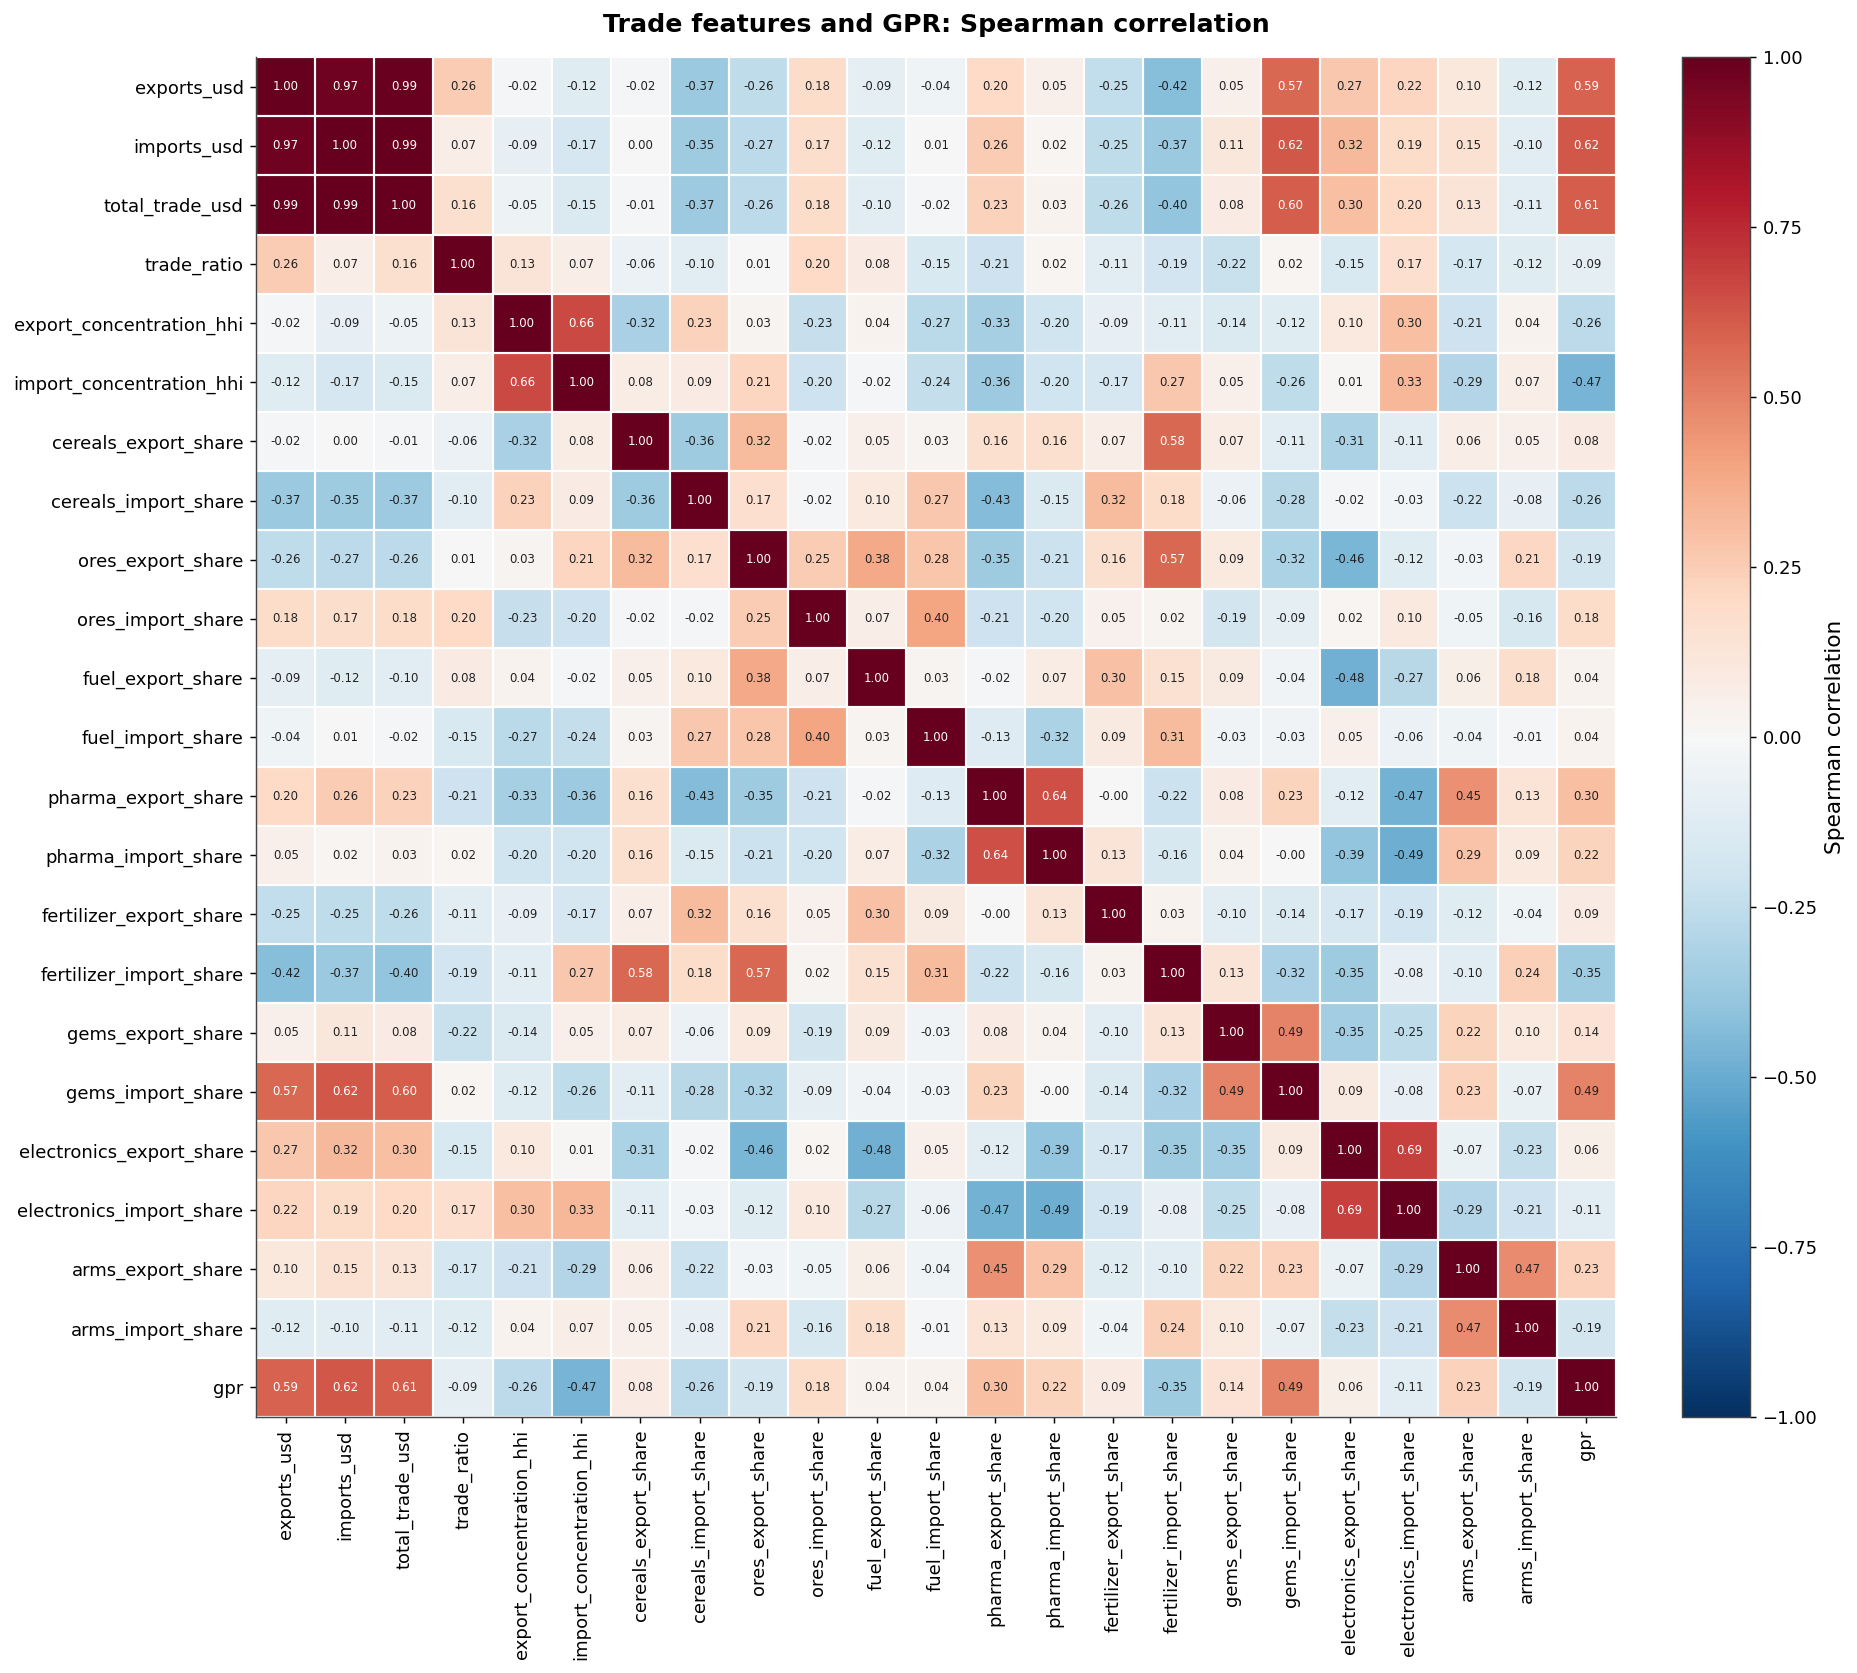

In [44]:
mh = m.merge(ei[["iso3", "year", "exports_usd", "imports_usd"]], on=["iso3", "year"], how="left")
cols = ["exports_usd", "imports_usd"] + feats + ["gpr"]
cm = mh[cols].corr(method="spearman")

fig, ax = plt.subplots(figsize=(15, 13))
im = ax.imshow(cm, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(cm))); ax.set_xticklabels(cm.columns, rotation=90)
ax.set_yticks(range(len(cm))); ax.set_yticklabels(cm.columns)
ax.set_xticks(np.arange(-.5, len(cm), 1), minor=True); ax.set_yticks(np.arange(-.5, len(cm), 1), minor=True)
ax.grid(which="major", visible=False); ax.grid(which="minor", color="white", linewidth=1.2)
ax.tick_params(which="minor", length=0)
for i in range(len(cm)):
    for j in range(len(cm)):
        v = cm.iloc[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=6.5,
                color="white" if abs(v) > 0.55 else "#222222")
cb = fig.colorbar(im, fraction=0.046, pad=0.04); cb.set_label("Spearman correlation")
ax.set_title("Trade features and GPR: Spearman correlation", pad=14)
fig.tight_layout(); plt.show()

Most feature pairs don't exceeds 0.9, except forimports, exports, and total trade. The strongest GPR links are total trade, gems import share, and import concentration.

I plot each country's average GPR against its average total trade over 2015 to 2024 to show the size effect, I observe that big traders tend to score higher on GPR.

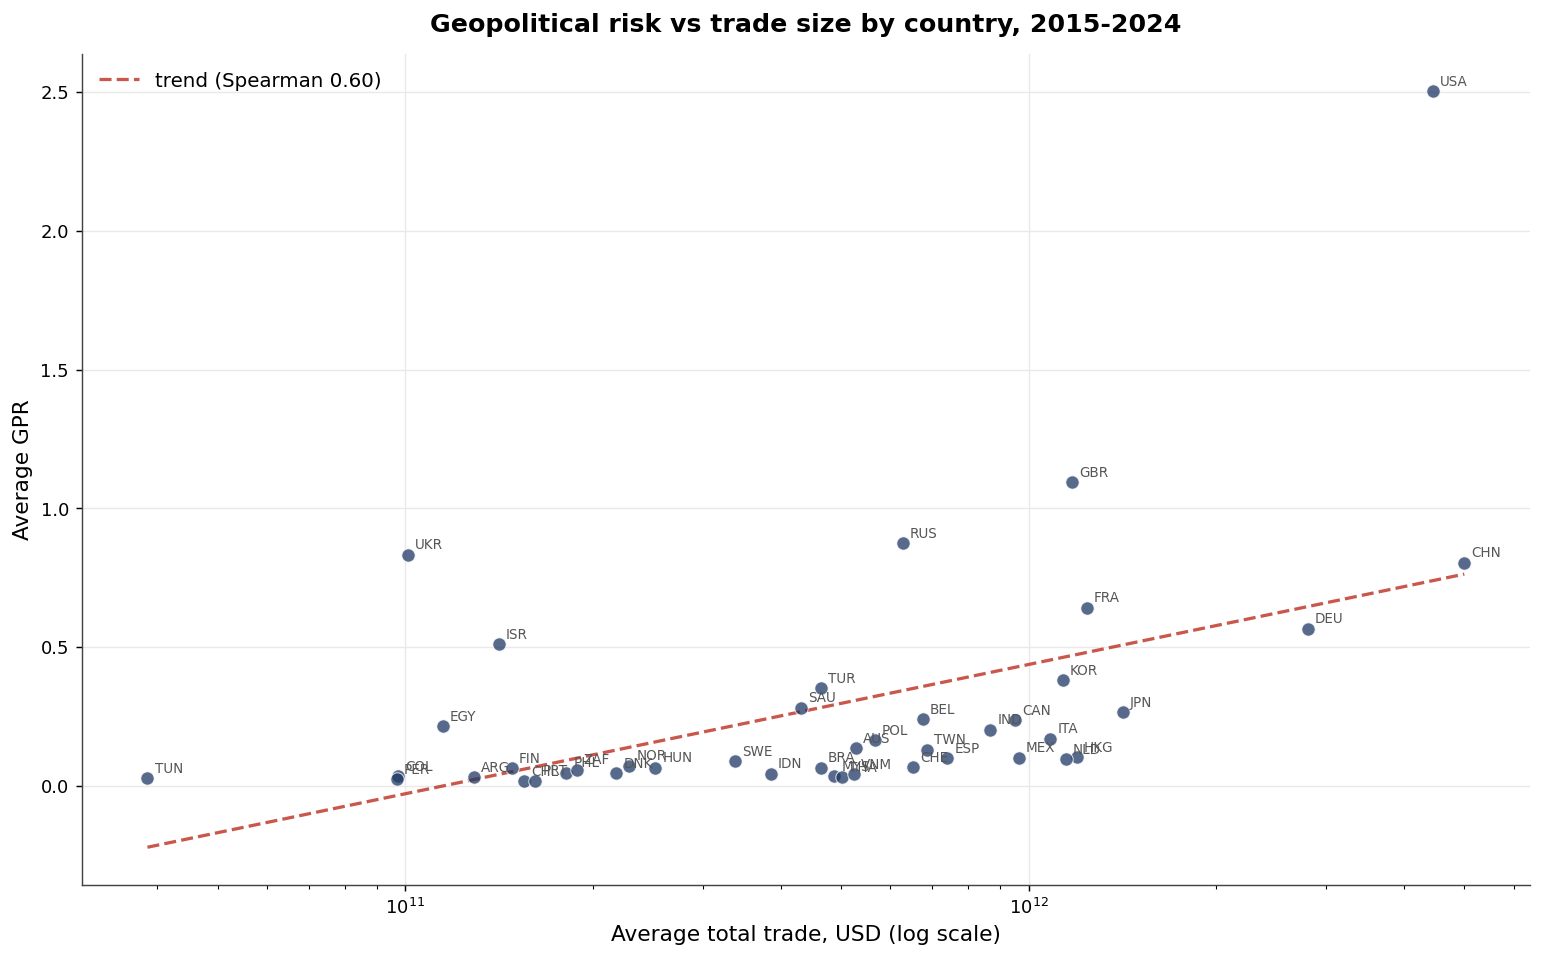

In [45]:
from scipy.stats import spearmanr

agg = m.groupby("iso3").agg(total_trade=("total_trade_usd", "mean"), gpr=("gpr", "mean")).reset_index()
rho = spearmanr(agg.total_trade, agg.gpr).statistic

fig, ax = plt.subplots(figsize=(12, 7.5))
ax.scatter(agg.total_trade, agg.gpr, s=55, color=NAVY, alpha=0.75, edgecolor="white", linewidth=0.6, zorder=3)
ax.set_xscale("log")
lx = np.log10(agg.total_trade); slope, intercept = np.polyfit(lx, agg.gpr, 1)
xs = np.linspace(lx.min(), lx.max(), 50)
ax.plot(10 ** xs, intercept + slope * xs, color=RED, lw=1.8, ls="--", alpha=0.85, zorder=2, label=f"trend (Spearman {rho:.2f})")
for _, r in agg.iterrows():
    ax.annotate(r.iso3, (r.total_trade, r.gpr), fontsize=7.5, color="#555555", xytext=(4, 3), textcoords="offset points")
ax.set_xlabel("Average total trade, USD (log scale)"); ax.set_ylabel("Average GPR")
ax.set_title("Geopolitical risk vs trade size by country, 2015-2024", pad=12)
ax.legend(loc="upper left"); fig.tight_layout(); plt.show()

Across countries the link is positive (Spearman 0.60): bigger traders tend to sit higher on GPR, which fits a news-based index favoring large, heavily-covered economies. The USA anchors the top right, with the UK, Russia, France, and China in the upper band.

The interesting countries are the ones off the trend line. Ukraine sits high and to the left, small total trade (~$100B) but very high GPR, driven by war rather than size. China sits a little low for its scale, the largest trader yet only moderate GPR, so it draws less news-risk per dollar of trade. So total trade explains the broad level of GPR but not the outliers, which is exactly why the model needs the other features beyond size.

I rank countries by their average import_concentration_hhi over 2015 to 2024 and show the 12 most supplier-concentrated against the 12 most diversified. High HHI (red) is the coercion-vulnerable end; low HHI (blue) spreads imports across many suppliers.

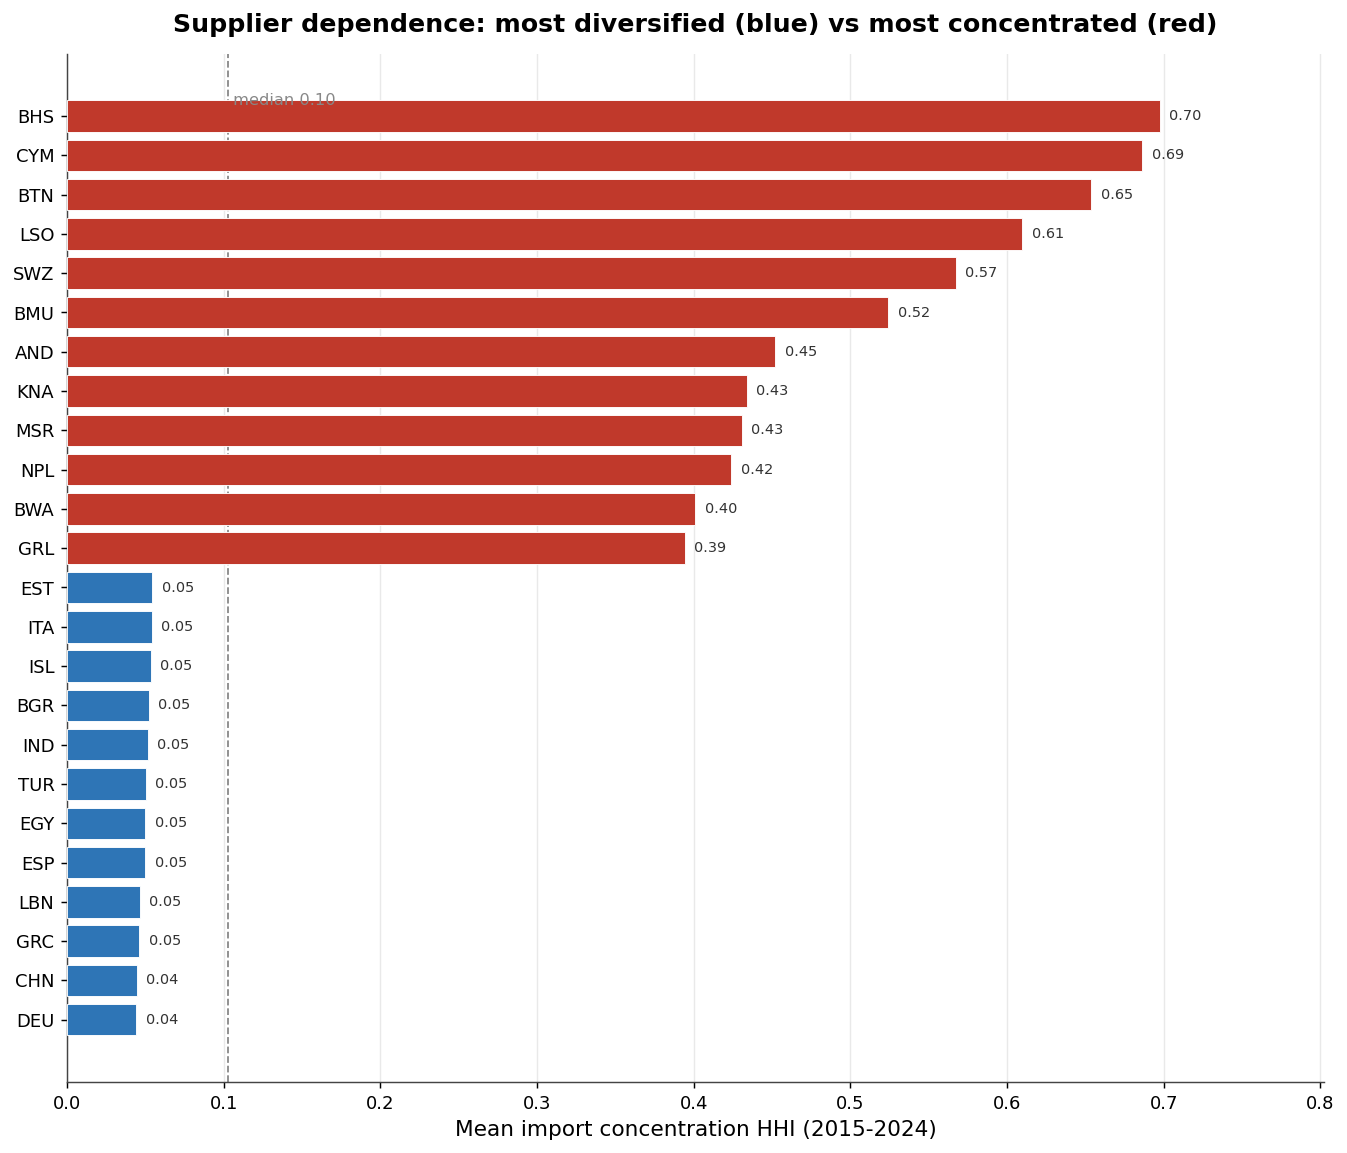

In [46]:
div = out.groupby("iso3")["import_concentration_hhi"].mean().dropna().sort_values()
ends = pd.concat([div.head(12), div.tail(12)])
colors = [BLUE] * 12 + [RED] * 12

fig, ax = plt.subplots(figsize=(10.5, 9))
bars = ax.barh(range(len(ends)), ends.values, color=colors, edgecolor="white", linewidth=0.5, zorder=3)
ax.set_yticks(range(len(ends))); ax.set_yticklabels(ends.index)
ax.axvline(div.median(), color="#888888", ls="--", lw=1, zorder=2)
ax.text(div.median(), len(ends) - 0.4, f" median {div.median():.2f}", color="#888888", fontsize=9, va="top")
for b, v in zip(bars, ends.values):
    ax.text(v + 0.006, b.get_y() + b.get_height() / 2, f"{v:.2f}", va="center", fontsize=8, color="#333333")
ax.set_xlabel("Mean import concentration HHI (2015-2024)")
ax.set_title("Supplier dependence: most diversified (blue) vs most concentrated (red)", pad=12)
ax.set_xlim(0, ends.max() * 1.15); ax.grid(axis="y", visible=False)
fig.tight_layout(); plt.show()

Tiny single-supplier economies top the concentrated end (Bahamas, Cayman, Bhutan, Lesotho), while large economies are the most diversified (Germany, China, Spain).

I show the top 30 traders by total trade as rows and the 8 export chapters as columns, colored by each country's mean export share. This reveals who specializes in what: fuel exporters, electronics hubs, resource economies.

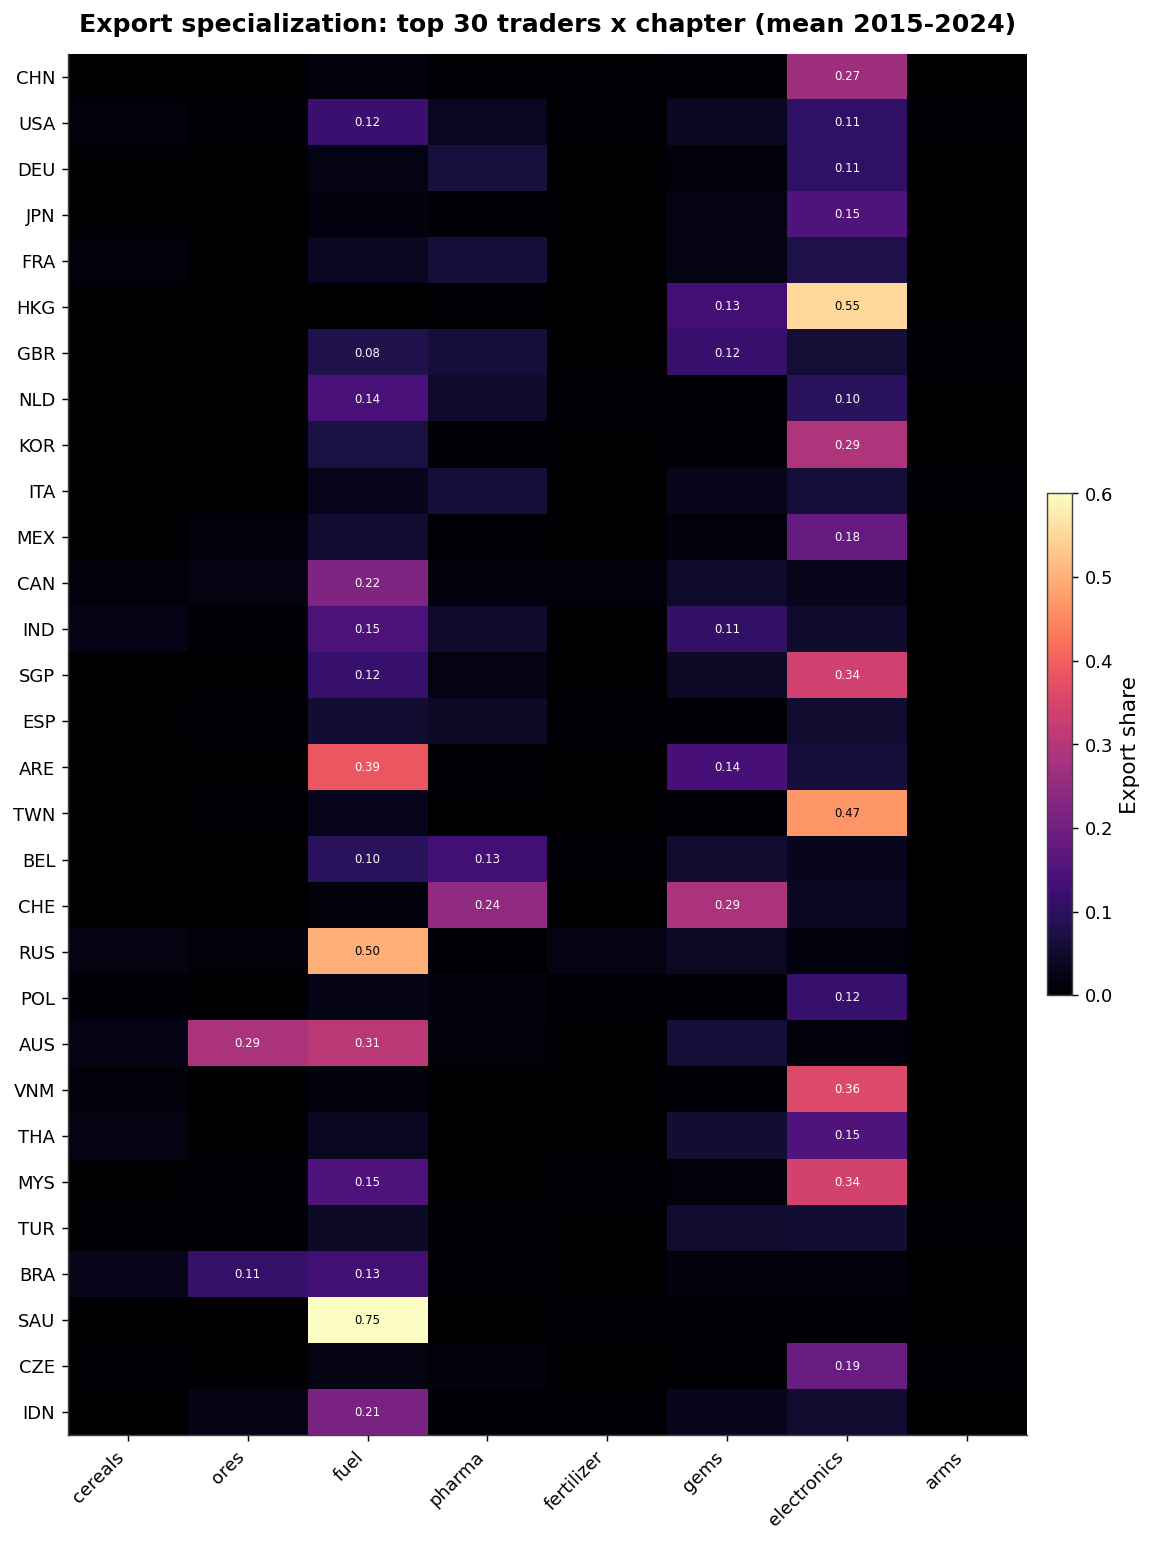

In [47]:
exp_cols = [f"{n}_export_share" for n in CH.values()]
top = out.groupby("iso3")["total_trade_usd"].mean().nlargest(30).index.tolist()
hmv = out[out.iso3.isin(top)].groupby("iso3")[exp_cols].mean().loc[top]
labels = [c.replace("_export_share", "") for c in exp_cols]

fig, ax = plt.subplots(figsize=(9, 12))
im = ax.imshow(hmv.values, cmap="magma", aspect="auto", vmin=0, vmax=0.6)
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticks(range(len(top))); ax.set_yticklabels(top)
ax.grid(False)
for i in range(len(top)):
    for j in range(len(labels)):
        v = hmv.values[i, j]
        if v >= 0.08:
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=6.5, color="white" if v < 0.45 else "black")
cb = fig.colorbar(im, fraction=0.025, pad=0.02); cb.set_label("Export share")
ax.set_title("Export specialization: top 30 traders x chapter (mean 2015-2024)", pad=12)
fig.tight_layout(); plt.show()

Clear specializations show up: Saudi Arabia, Russia, and the UAE on fuel; Hong Kong, Taiwan, Vietnam, and Singapore on electronics.

## 5. Validate and Save

I check the saved table for duplicate rows, duplicate iso3-year keys, and missing values, then look at which rows carry the few NaNs.

In [48]:
print("duplicate full rows :", out.duplicated().sum())
print("duplicate iso3-year :", out.duplicated(["iso3", "year"]).sum())

miss = out.isna().sum()
miss = miss[miss > 0].sort_values(ascending=False)
print("columns with missing values:", len(miss))
miss.to_frame("n_missing").assign(pct=lambda d: (d["n_missing"] / len(out) * 100).round(2))

duplicate full rows : 0
duplicate iso3-year : 0
columns with missing values: 3


,n_missing,pct
trade_ratio,3,0.18
import_concentration_hhi,2,0.12
export_concentration_hhi,1,0.06


In [49]:
nacols = ["trade_ratio", "export_concentration_hhi", "import_concentration_hhi"]
out[out[nacols].isna().any(axis=1)][["iso3", "year", "total_trade_usd"] + nacols]

,iso3,year,total_trade_usd,trade_ratio,export_concentration_hhi,import_concentration_hhi
415,CYM,2015,9.154544e+08,NaN,NaN,0.730662
742,IRQ,2015,4.940258e+10,NaN,0.992278,NaN
743,IRQ,2016,4.377402e+10,NaN,0.995884,NaN


The clean table has no duplicate rows and no duplicate iso3-year keys. Only 3 cells are missing, all in the tot features and all from one-sided reporting: Cayman Islands 2015 reported imports but no exports (so trade_ratio and export_concentration_hhi are undefined), and Iraq 2015 and 2016 reported exports but no imports (so trade_ratio and import_concentration_hhi are undefined). 

In [50]:
os.makedirs(OUT_DIR, exist_ok=True)
path = f"{OUT_DIR}/comtrade_clean.csv"
out.to_csv(path, index=False)
print("saved:", path, "|", out.shape)

saved: /Users/oussamaennaciri/Documents/Education/Academique/Regis/MSDS692 S40 Data Science Practicum/data/interim/comtrade/comtrade_clean.csv | (1690, 22)


Claude (Anthropic) was used only as a collaborator for writing code and polishing the notebooks. All analytical decisions, interpretations, and research were conducted independently by me.